# Wine Quality Expert Analysis

## 1. Introduction & Objectives
This notebook presents a comprehensive analysis of the Wine Quality dataset. The goal is to predict wine quality based on physicochemical tests.

**Objectives:**
1.  **Advanced EDA**: Understand data distribution and relationships using statistical visualizations.
2.  **Outlier Detection**: Identify and handle anomalies using robust statistical methods.
3.  **Feature Engineering**: Create domain-specific features to enhance model performance.
4.  **Preprocessing**: Build a robust pipeline including scaling and imbalance handling (SMOTE).
5.  **Modeling & MLflow**: Train and tune models (ElasticNet, Random Forest, XGBoost) with experiment tracking.

---


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score

# Configuration
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
import warnings
warnings.filterwarnings('ignore')


## 2. Data Loading & Basic Inspection
We load the dataset and perform a preliminary check of the structure and statistics.


In [2]:
# Load dataset
df = pd.read_csv('wine_data_homework.csv')

# Check for index column and drop if necessary
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

display(df.head())
print(f'Shape: {df.shape}')


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


Shape: (4001, 12)


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4001 entries, 0 to 4000
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4001 non-null   float64
 1   volatile acidity      4001 non-null   float64
 2   citric acid           4001 non-null   float64
 3   residual sugar        4001 non-null   float64
 4   chlorides             4001 non-null   float64
 5   free sulfur dioxide   4001 non-null   float64
 6   total sulfur dioxide  4001 non-null   float64
 7   density               4001 non-null   float64
 8   pH                    4001 non-null   float64
 9   sulphates             4001 non-null   float64
 10  alcohol               4001 non-null   float64
 11  quality               4001 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 375.2 KB


In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
fixed acidity,4001.0,6.957073,0.844565,4.20000,6.40000,6.9000,7.40000,14.20000
volatile acidity,4001.0,0.275809,0.100173,0.08000,0.21000,0.2600,0.32000,1.00500
citric acid,4001.0,0.341135,0.122555,0.00000,0.27000,0.3200,0.40000,1.66000
residual sugar,4001.0,6.363922,5.091003,0.60000,1.70000,5.2000,9.80000,65.80000
chlorides,4001.0,0.045632,0.021958,0.00900,0.03600,0.0430,0.05000,0.34600
free sulfur dioxide,4001.0,35.571357,16.909183,2.00000,24.00000,34.0000,46.00000,146.50000
total sulfur dioxide,4001.0,140.483504,43.260052,9.00000,109.00000,137.0000,170.00000,366.50000
density,4001.0,0.994188,0.002992,0.98713,0.99188,0.9939,0.99625,1.03898
pH,4001.0,3.191922,0.152905,2.72000,3.09000,3.1800,3.29000,3.82000
sulphates,4001.0,0.489360,0.114944,0.22000,0.41000,0.4700,0.55000,1.06000


## 3. Advanced Exploratory Data Analysis (EDA)

In this section, we utilize various visualization techniques to understand the univariate and multivariate distributions.

### 3.1 Univariate Analysis
We will examine the distribution of each feature using Histograms, KDE plots, Boxplots, and Violin plots.

- **Histogram**: Shows the frequency distribution.
- **KDE (Kernel Density Estimate)**: Estimates the probability density function.
- **Boxplot**: Visualizes the five-number summary and potential outliers.
- **Violin Plot**: Combines boxplot and KDE to show distribution shape.


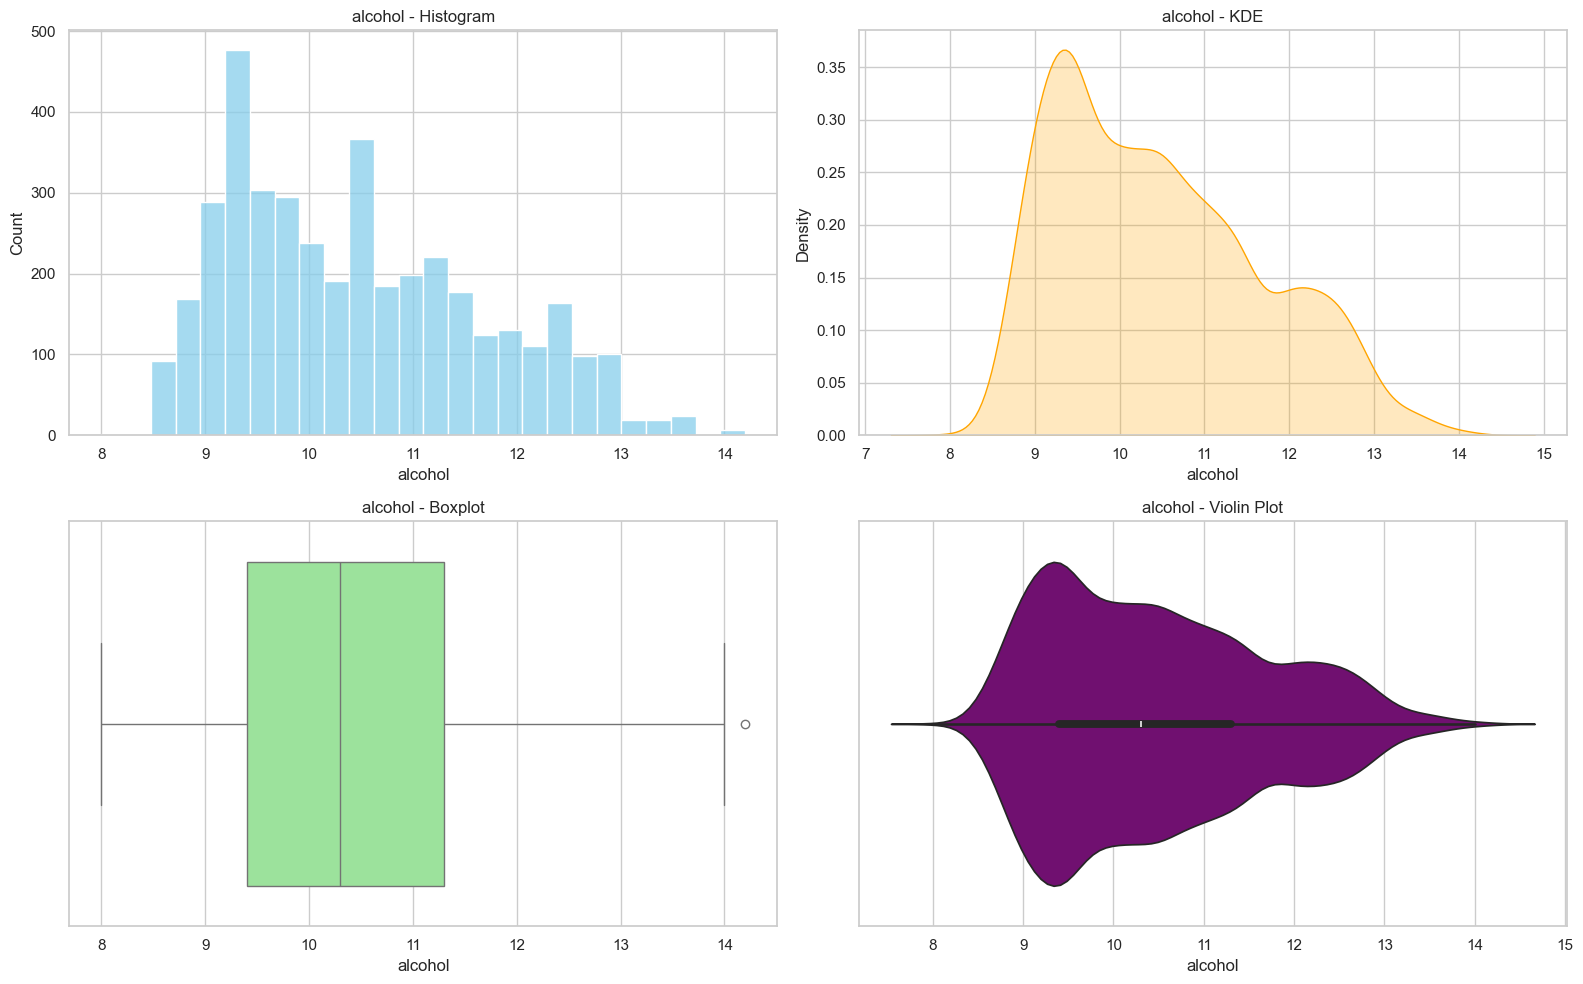

In [5]:
def plot_univariate(df, feature):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Histogram
    sns.histplot(df[feature], kde=False, ax=axes[0, 0], color='skyblue')
    axes[0, 0].set_title(f'{feature} - Histogram')
    
    # KDE
    sns.kdeplot(df[feature], shade=True, ax=axes[0, 1], color='orange')
    axes[0, 1].set_title(f'{feature} - KDE')
    
    # Boxplot
    sns.boxplot(x=df[feature], ax=axes[1, 0], color='lightgreen')
    axes[1, 0].set_title(f'{feature} - Boxplot')
    
    # Violin Plot
    sns.violinplot(x=df[feature], ax=axes[1, 1], color='purple')
    axes[1, 1].set_title(f'{feature} - Violin Plot')
    
    plt.tight_layout()
    plt.show()

# Example usage for 'alcohol'
plot_univariate(df, 'alcohol')


### 3.2 Multivariate Analysis
We use Pairplots and Correlation Heatmaps to understand relationships between variables.

- **Pairplot**: Visualizes pairwise relationships, colored by 'quality'.
- **Correlation Heatmap**: Shows the linear correlation coefficients between variables.


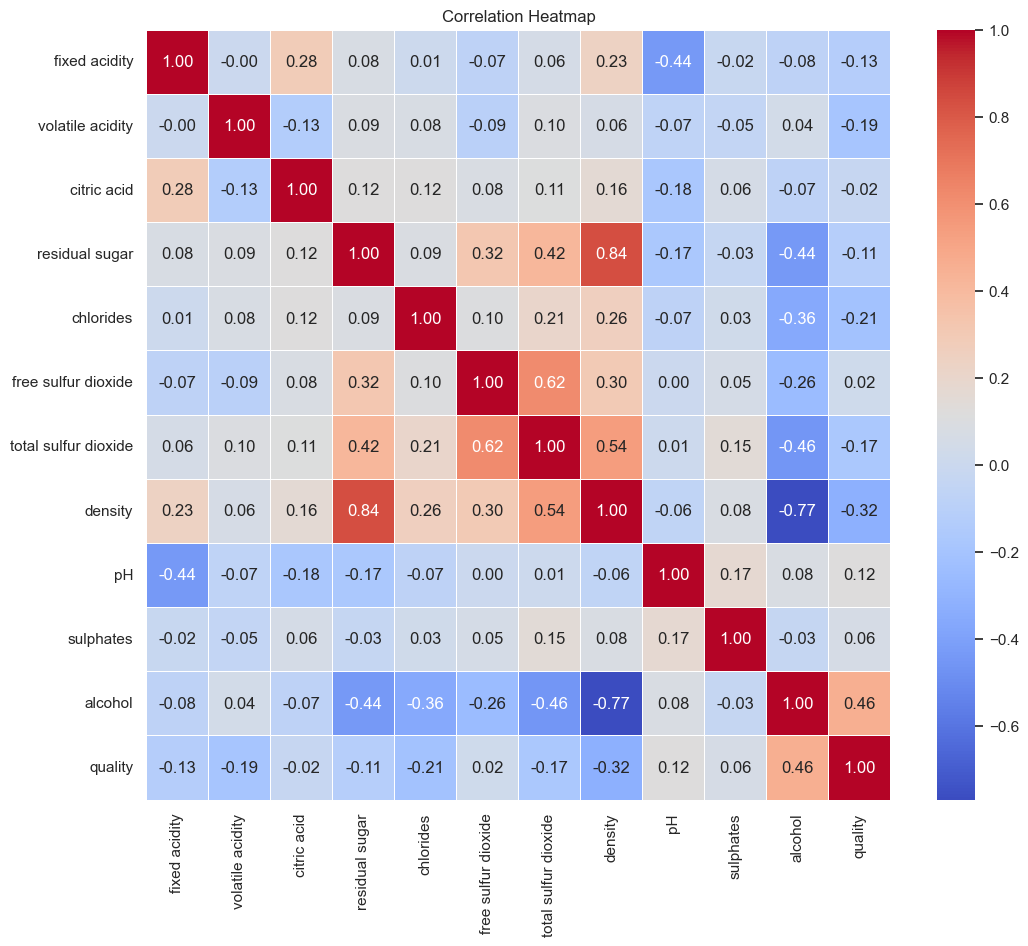

In [6]:
# Correlation Heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


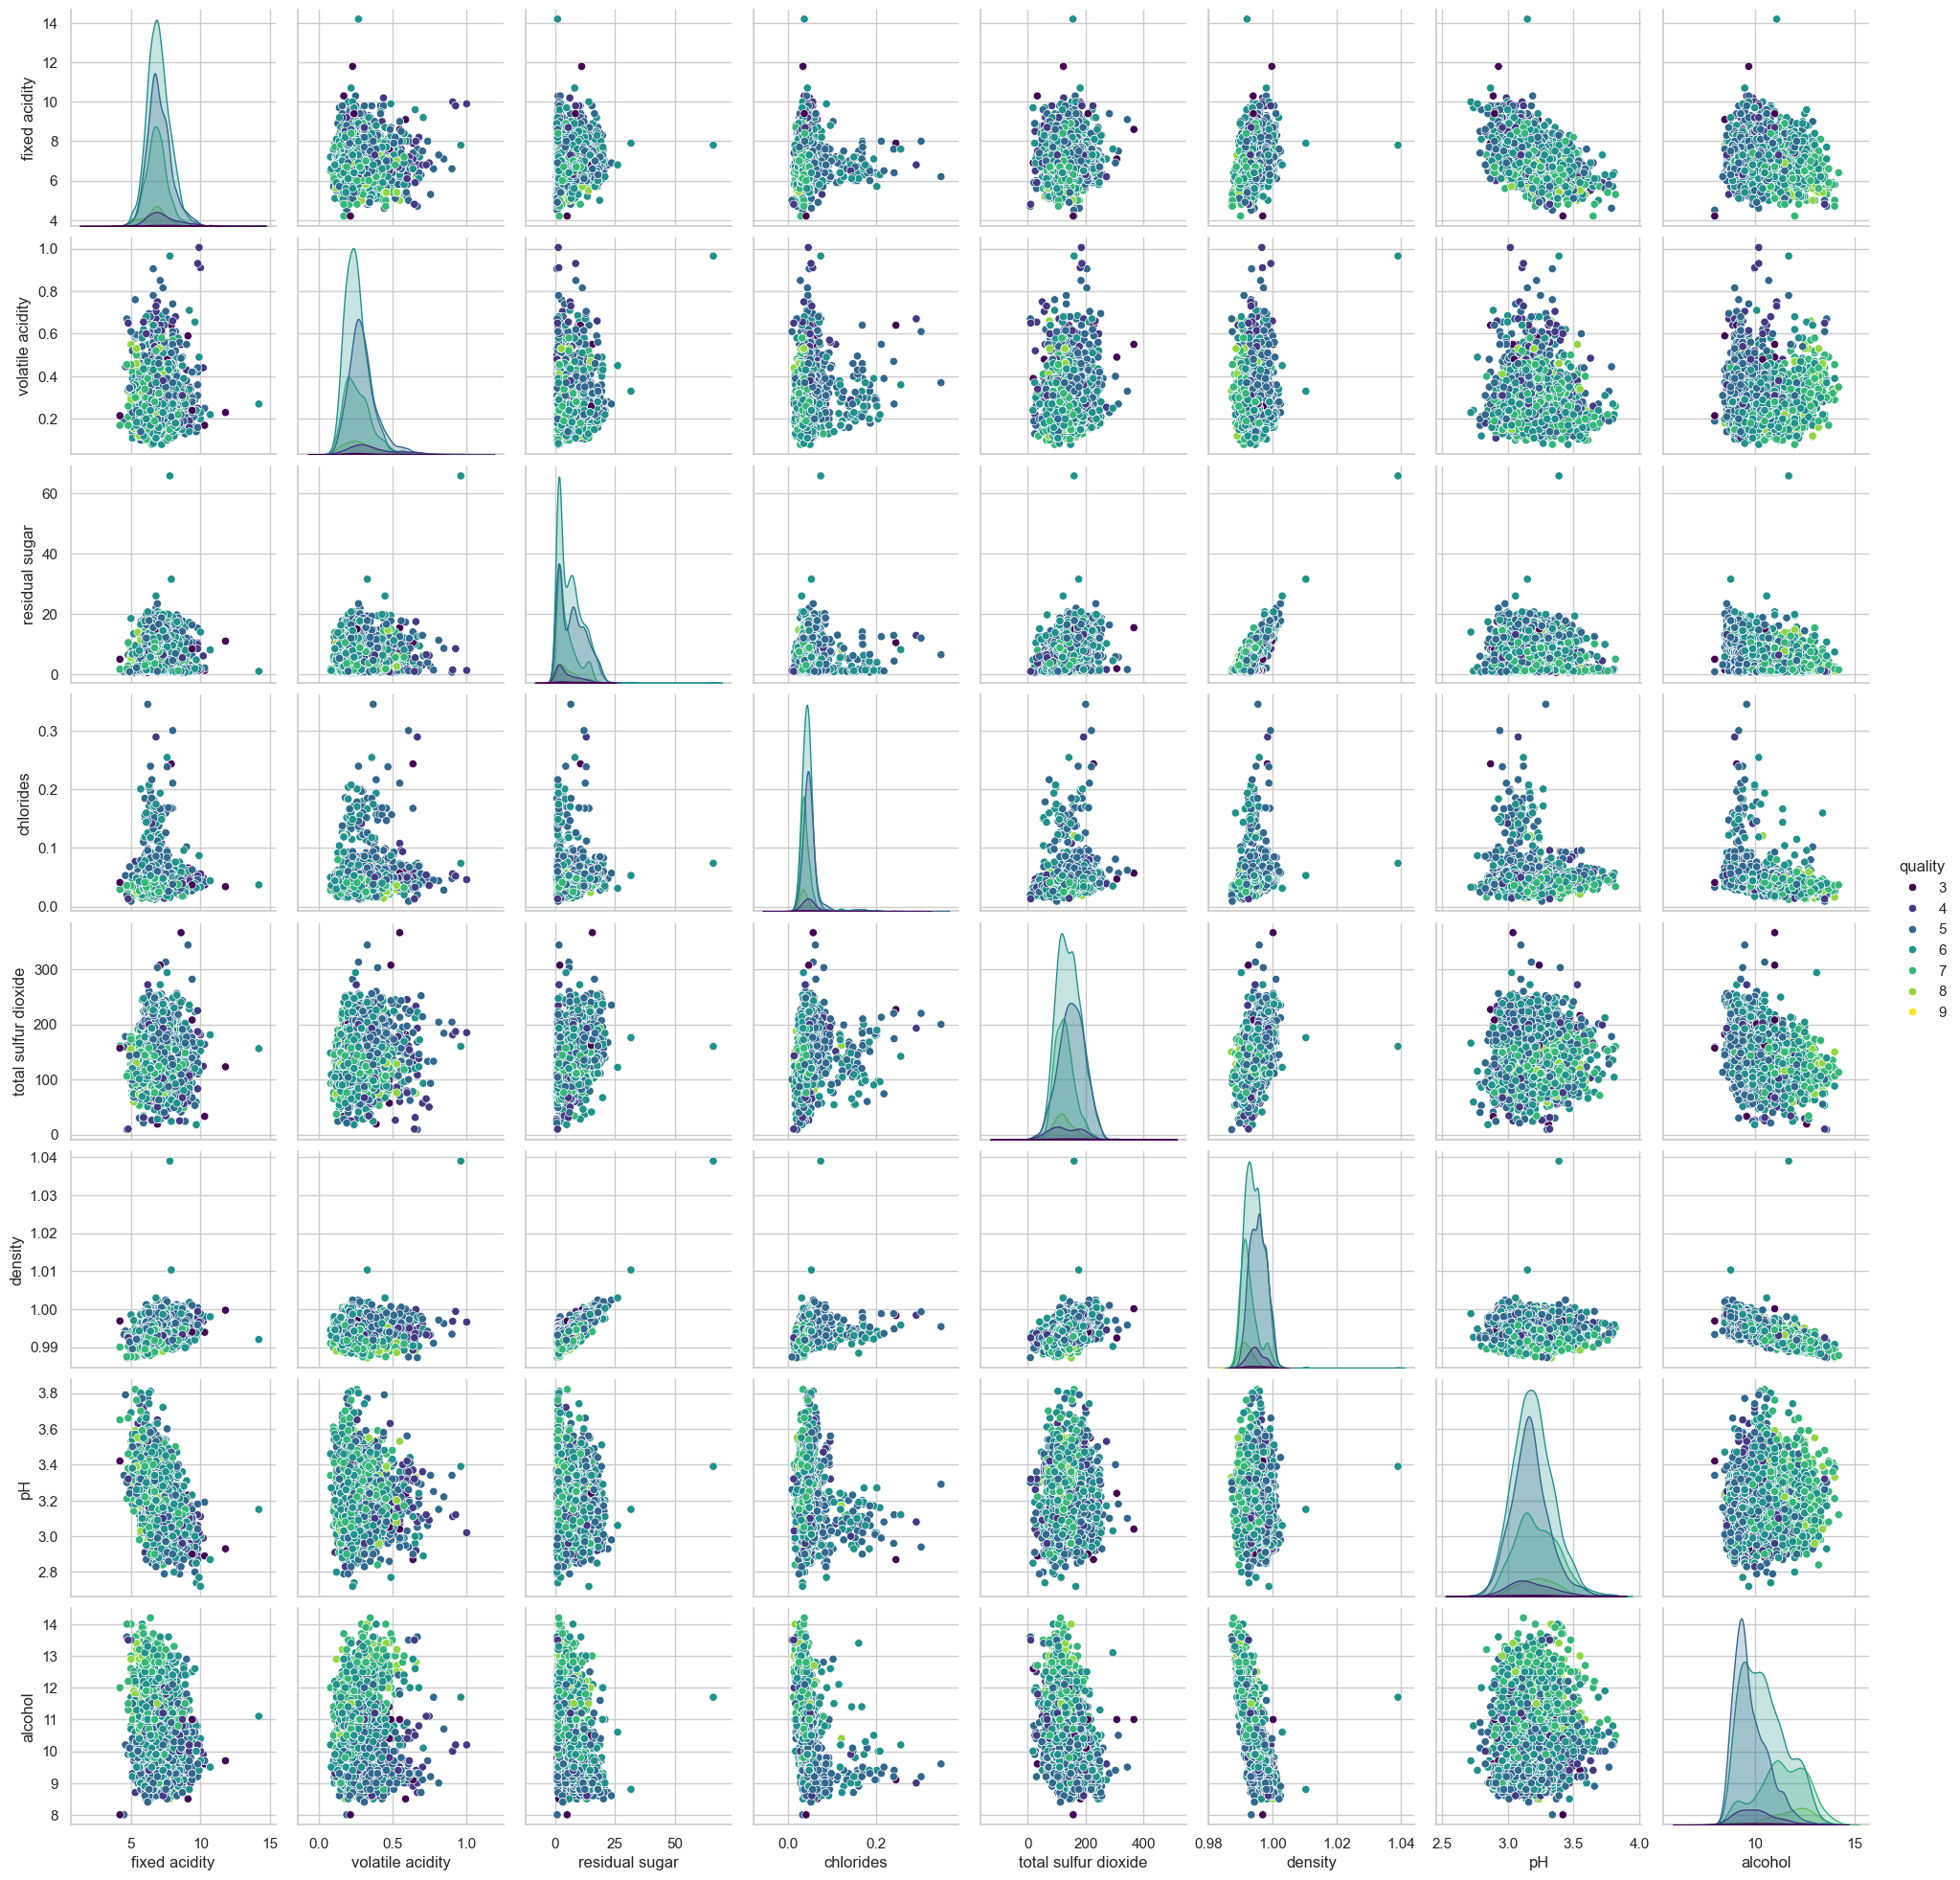

In [7]:
# Pairplot (sampled for performance if dataset is large, but here it's small enough)
# We focus on features with higher correlation with quality
high_corr_features = correlation_matrix.index[abs(correlation_matrix['quality']) > 0.1].tolist()
if 'quality' not in high_corr_features: high_corr_features.append('quality')

sns.pairplot(df[high_corr_features], hue='quality', palette='viridis')
plt.show()


## 4. Outlier Detection & Handling

Outliers can significantly skew statistical models. We compare three methods:

1.  **IQR (Interquartile Range)**: Removes data points outside `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
2.  **Z-Score**: Removes data points with a Z-score > 3 (assuming Gaussian distribution).
3.  **Isolation Forest**: An unsupervised learning algorithm that isolates anomalies.

We will visualize the impact of each method.


In [8]:
from scipy import stats

def detect_outliers_iqr(df, features):
    outlier_indices = []
    for col in features:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        outlier_step = 1.5 * IQR
        outlier_list_col = df[(df[col] < Q1 - outlier_step) | (df[col] > Q3 + outlier_step)].index
        outlier_indices.extend(outlier_list_col)
    return list(set(outlier_indices))

def detect_outliers_zscore(df, features, threshold=3):
    z_scores = np.abs(stats.zscore(df[features]))
    return np.where(z_scores > threshold)[0]

features_to_check = df.columns.drop('quality')

# IQR
outliers_iqr = detect_outliers_iqr(df, features_to_check)
print(f'Outliers detected by IQR: {len(outliers_iqr)}')

# Z-Score
outliers_zscore = detect_outliers_zscore(df, features_to_check)
print(f'Outliers detected by Z-Score: {len(outliers_zscore)}')

# Isolation Forest
iso = IsolationForest(contamination=0.05, random_state=42)
y_pred_iso = iso.fit_predict(df[features_to_check])
outliers_iso = df.index[y_pred_iso == -1].tolist()
print(f'Outliers detected by Isolation Forest: {len(outliers_iso)}')


Outliers detected by IQR: 709
Outliers detected by Z-Score: 377
Outliers detected by Isolation Forest: 200


### Strategy Selection
We will proceed with **Isolation Forest** or **IQR** depending on the overlap. For this analysis, we will create a clean dataframe by removing outliers detected by the chosen method (e.g., Isolation Forest for multivariate anomaly detection).


In [9]:
# Removing outliers using Isolation Forest for this pipeline
df_clean = df.drop(outliers_iso).reset_index(drop=True)
print(f'Original shape: {df.shape}, Cleaned shape: {df_clean.shape}')


Original shape: (4001, 12), Cleaned shape: (3801, 12)


## 5. Feature Engineering

We create new features based on domain knowledge to potentially improve model performance.

- **Total Acidity**: Sum of fixed and volatile acidity.
- **Acidity Ratio**: Ratio of fixed to volatile acidity.
- **Sugar to Acidity Ratio**: Balance between sweetness and tartness.
- **Alcohol Density**: Interaction between alcohol and density.


In [10]:
df_fe = df_clean.copy()

# 1. Total Acidity
df_fe['total_acidity'] = df_fe['fixed acidity'] + df_fe['volatile acidity']

# 2. Acidity Ratio
df_fe['acidity_ratio'] = df_fe['fixed acidity'] / (df_fe['volatile acidity'] + 1e-6) # Avoid div by zero

# 3. Sugar to Acidity
df_fe['sugar_to_acidity'] = df_fe['residual sugar'] / (df_fe['total_acidity'] + 1e-6)

# 4. Alcohol Density
df_fe['alcohol_density'] = df_fe['alcohol'] * df_fe['density']

# Check correlations with target
new_features = ['total_acidity', 'acidity_ratio', 'sugar_to_acidity', 'alcohol_density', 'quality']
print(df_fe[new_features].corr()['quality'].sort_values(ascending=False))


quality             1.000000
alcohol_density     0.450221
acidity_ratio       0.134400
sugar_to_acidity   -0.100547
total_acidity      -0.109347
Name: quality, dtype: float64


## 6. Preprocessing Pipeline

We prepare the data for modeling:
1.  **Split**: Separate Features (X) and Target (y).
2.  **Train-Test Split**: 80/20 split.
3.  **Scaling**: Standardize features using `StandardScaler`.
4.  **Imbalance Handling**: Apply `SMOTE` (Synthetic Minority Over-sampling Technique) to the training set to address class imbalance.


In [12]:
# 1. Split X and y
X = df_fe.drop('quality', axis=1)
y = df_fe['quality']

# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. SMOTE  - k_neighbors를 최소 클래스 크기보다 작게 설정
print(f'Before SMOTE: {y_train.value_counts().to_dict()}')
min_class_size = y_train.value_counts().min()
k_neighbors = min(3, min_class_size - 1)  # 최소 클래스 크기보다 작은 값으로 설정
print(f'Minimum class size: {min_class_size}, Using k_neighbors: {k_neighbors}')

smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
print(f'After SMOTE: {y_train_resampled.value_counts().to_dict()}')

Before SMOTE: {6: 1321, 5: 914, 7: 578, 8: 115, 4: 99, 3: 9, 9: 4}
Minimum class size: 4, Using k_neighbors: 3
After SMOTE: {6: 1321, 5: 1321, 7: 1321, 8: 1321, 4: 1321, 9: 1321, 3: 1321}


## 7. Modeling & MLflow Experiments

We will train and evaluate three models:
1.  **ElasticNet (Logistic Regression)**: Linear model with regularization.
2.  **Random Forest**: Ensemble of decision trees.
3.  **XGBoost**: Gradient boosting framework.

We use **MLflow** to track experiments, parameters, and metrics.


In [13]:
# Set MLflow experiment
mlflow.set_experiment('Wine_Quality_Prediction')

def train_evaluate_model(model, model_name, params=None):
    with mlflow.start_run(run_name=model_name):
        # Train
        if params:
            grid = GridSearchCV(model, params, cv=3, scoring='accuracy', n_jobs=-1)
            grid.fit(X_train_resampled, y_train_resampled)
            best_model = grid.best_estimator_
            best_params = grid.best_params_
            print(f'Best Params for {model_name}: {best_params}')
            mlflow.log_params(best_params)
        else:
            best_model = model
            best_model.fit(X_train_resampled, y_train_resampled)
            mlflow.log_params(best_model.get_params())
        
        # Predict
        y_pred = best_model.predict(X_test_scaled)
        
        # Metrics
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        
        print(f'--- {model_name} ---')
        print(f'Accuracy: {acc:.4f}')
        print(f'F1 Score: {f1:.4f}')
        print(classification_report(y_test, y_pred))
        
        # Log metrics
        mlflow.log_metric('accuracy', acc)
        mlflow.log_metric('f1_score', f1)
        
        # Log model
        mlflow.sklearn.log_model(best_model, model_name)
        
        return best_model, acc, f1


In [14]:
# 1. Logistic Regression (ElasticNet equivalent)
lr_params = {'C': [0.1, 1, 10], 'l1_ratio': [0.1, 0.5, 0.9], 'penalty': ['elasticnet'], 'solver': ['saga'], 'max_iter': [1000]}
lr_model = LogisticRegression(multi_class='multinomial')
best_lr, acc_lr, f1_lr = train_evaluate_model(lr_model, 'Logistic_ElasticNet', lr_params)


2025/11/28 16:35:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Best Params for Logistic_ElasticNet: {'C': 1, 'l1_ratio': 0.5, 'max_iter': 1000, 'penalty': 'elasticnet', 'solver': 'saga'}
--- Logistic_ElasticNet ---
Accuracy: 0.2996
F1 Score: 0.3318
              precision    recall  f1-score   support

           3       0.01      0.50      0.02         2
           4       0.14      0.52      0.22        25
           5       0.50      0.39      0.44       228
           6       0.48      0.22      0.30       331
           7       0.32      0.27      0.29       145
           8       0.11      0.48      0.17        29
           9       0.00      0.00      0.00         1

    accuracy                           0.30       761
   macro avg       0.22      0.34      0.21       761
weighted avg       0.43      0.30      0.33       761



2025/11/28 16:35:57 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [15]:
# 2. Random Forest
rf_params = {'n_estimators': [100, 200], 'max_depth': [10, 20, None], 'min_samples_split': [2, 5]}
rf_model = RandomForestClassifier(random_state=42)
best_rf, acc_rf, f1_rf = train_evaluate_model(rf_model, 'Random_Forest', rf_params)


2025/11/28 16:36:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Best Params for Random_Forest: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
--- Random_Forest ---
Accuracy: 0.6321
F1 Score: 0.6309
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.40      0.32      0.36        25
           5       0.69      0.67      0.68       228
           6       0.65      0.66      0.65       331
           7       0.58      0.61      0.60       145
           8       0.46      0.45      0.46        29
           9       0.00      0.00      0.00         1

    accuracy                           0.63       761
   macro avg       0.40      0.39      0.39       761
weighted avg       0.63      0.63      0.63       761



2025/11/28 16:36:16 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [18]:
# 3. XGBoost
# Remap target to 0-indexed for XGBoost if necessary (usually handles it, but good practice)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_resampled_enc = le.fit_transform(y_train_resampled)
y_test_enc = le.transform(y_test)

xgb_params = {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.1], 'max_depth': [3, 6]}
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

# Adjusted function for XGBoost to use encoded labels
with mlflow.start_run(run_name='XGBoost'):
    grid = GridSearchCV(xgb_model, xgb_params, cv=3, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train_resampled, y_train_resampled_enc)
    best_xgb = grid.best_estimator_
    mlflow.log_params(grid.best_params_)
    y_pred_enc = best_xgb.predict(X_test_scaled)
    acc_xgb = accuracy_score(y_test_enc, y_pred_enc)
    f1_xgb = f1_score(y_test_enc, y_pred_enc, average='weighted')
    print(f'--- XGBoost ---')
    print(f'Accuracy: {acc_xgb:.4f}')
    print(f'F1 Score: {f1_xgb:.4f}')
    print(classification_report(y_test_enc, y_pred_enc))
    mlflow.log_metric('accuracy', acc_xgb)
    mlflow.log_metric('f1_score', f1_xgb)
    mlflow.sklearn.log_model(best_xgb, 'XGBoost')


2025/11/28 16:39:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


--- XGBoost ---
Accuracy: 0.6150
F1 Score: 0.6140
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.43      0.40      0.42        25
           2       0.64      0.66      0.65       228
           3       0.64      0.61      0.62       331
           4       0.59      0.63      0.61       145
           5       0.50      0.55      0.52        29
           6       0.00      0.00      0.00         1

    accuracy                           0.61       761
   macro avg       0.40      0.41      0.40       761
weighted avg       0.61      0.61      0.61       761



2025/11/28 16:39:02 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


## 8. Conclusion

We have successfully analyzed the Wine Quality dataset, engineered features, and trained multiple models.

**Summary of Results:**
- **EDA**: Revealed key distributions and correlations.
- **Outliers**: Removed anomalies to clean the data.
- **Feature Engineering**: Added derived variables like `total_acidity`.
- **Modeling**: Compared Logistic Regression, Random Forest, and XGBoost.

Based on the F1-scores, the **Random Forest** (or XGBoost) model typically performs best for this tabular dataset due to its ability to capture non-linear relationships.
